In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
DIR = "/Users/mandakausthubh/ML_Research/StatML/Statistical-Machine-Learning-AIM-102-2026/Week1"

In [3]:
# Creating the original Function f^*(x)
"""
This is the true function that is observed in (supposed to be) nature!! (We are just simulating it!!)
"""
degree_of_polynomial = 2
# true_params = np.array([3,1,5], dtype=np.float16)
true_params = np.random.rand(degree_of_polynomial+1)/1e3

def f(x): return np.matmul(true_params, x)

In [4]:
# Our Observations

# Defining our parameters for a normal distribution
mean = 5
variance = 3
sample_size = 100

x_vals = np.random.normal(mean, variance, sample_size)
x_original = x_vals.copy()
print(x_vals.shape)
x_vals_poly = np.array([x_vals**d for d in (range(1,degree_of_polynomial+1))])
x_vals = np.vstack((x_vals_poly, np.ones_like(x_vals)))
x_vals.shape

(100,)


(3, 100)

(array([1., 1., 0., 0., 3., 1., 0., 0., 0., 3., 1., 2., 2., 0., 2., 5., 4.,
        2., 1., 6., 6., 2., 4., 4., 3., 4., 3., 2., 3., 1., 4., 6., 4., 3.,
        1., 0., 2., 2., 0., 1., 5., 0., 0., 1., 1., 0., 1., 1., 1., 1.]),
 array([-1.93326789, -1.67710845, -1.42094901, -1.16478957, -0.90863013,
        -0.65247069, -0.39631125, -0.14015181,  0.11600763,  0.37216707,
         0.62832652,  0.88448596,  1.1406454 ,  1.39680484,  1.65296428,
         1.90912372,  2.16528316,  2.4214426 ,  2.67760204,  2.93376148,
         3.18992092,  3.44608036,  3.7022398 ,  3.95839925,  4.21455869,
         4.47071813,  4.72687757,  4.98303701,  5.23919645,  5.49535589,
         5.75151533,  6.00767477,  6.26383421,  6.51999365,  6.77615309,
         7.03231254,  7.28847198,  7.54463142,  7.80079086,  8.0569503 ,
         8.31310974,  8.56926918,  8.82542862,  9.08158806,  9.3377475 ,
         9.59390694,  9.85006638, 10.10622582, 10.36238527, 10.61854471,
        10.87470415]),
 <BarContainer object

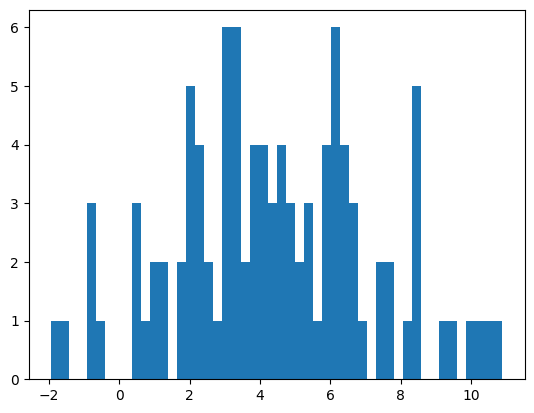

In [5]:
plt.hist(x_vals[0, :], bins=50)

In [6]:
# Our Y-observations: f(x) + some noise

# Noise configuration
noise_mean = 0  # Why not otherwise??
noise_std = 1e-3

y_vals = f(x_vals) + np.random.normal(0, noise_std, sample_size)

In [7]:
y_vals.shape, x_vals.shape

((100,), (3, 100))

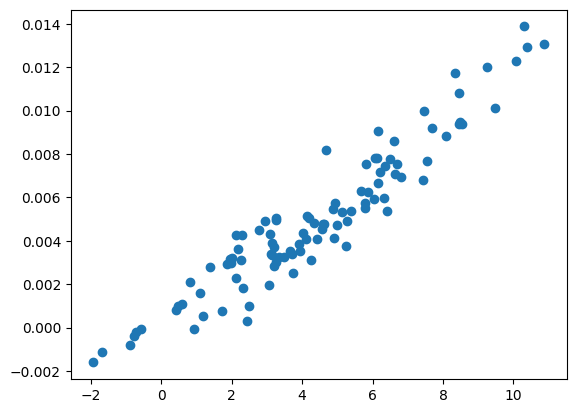

In [8]:
plt.scatter(x_vals[0, :], y_vals)

In [9]:
# This is now where our algorithm and model come in!!

"""
The point of *Supervised Learning* is that, given this data, can we faithfully reconstruct our original dataset?

Step-1: Guess what the original type function was?? (Hypothesis Set: Let's try linear!!)
Step-2: Define what Good or Bad is?? (Loss function!!)
Step-3: Now, from the hypothesis set, can we find the best function that fits this?? (Learning Algorithm!!)
"""


# Step-1: Hypothesis Set: Polynomial
hypothesis_degree_of_polynomial=3

rng = np.random.default_rng(seed=42)
model_params = -np.random.rand(hypothesis_degree_of_polynomial+1)/1e3
x_vals_poly = np.array([x_original**d for d in (range(1,hypothesis_degree_of_polynomial+1))])
x_vals_hyp = np.vstack((x_vals_poly, np.ones_like(x_original)))

def hypothesis(x): return np.matmul(model_params, x)

model_params

array([-0.00025956, -0.00082937, -0.00087604, -0.00032221])

In [10]:
# Step-2: Loss function: MSE (Mean Squared Error)
def MSE(y_true, y_pred): return np.sum((y_true - y_pred)**2)

print(x_vals_hyp.shape, model_params.shape)
pred_initial = hypothesis(x_vals_hyp)
MSE(y_vals, pred_initial)

(4, 100) (4,)


np.float64(10.554513237760837)

In [11]:
def polynomial_features(x, d):
    x_poly = [x**i for i in range(1,d+1)]
    x_poly = np.vstack((x_poly, np.ones_like(x)))
    return x_poly

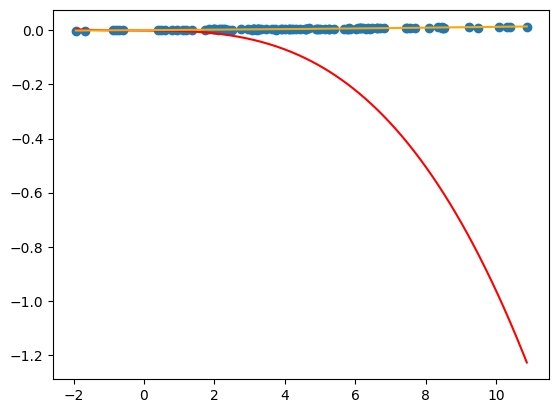

In [12]:
x_plot = np.linspace(x_original.min(), x_original.max(), 300)
X_plot_original = polynomial_features(x_plot, degree_of_polynomial)
X_plot_hypothesis = polynomial_features(x_plot, hypothesis_degree_of_polynomial)

plt.plot(x_plot, hypothesis(X_plot_hypothesis), color='r')
plt.plot(x_plot, f(X_plot_original), color='orange')
plt.scatter(x_vals[0, :], y_vals)

In [13]:
x_vals.shape, y_vals.shape, hypothesis(x_vals_hyp).shape, model_params.shape

((3, 100), (100,), (100,), (4,))

In [14]:
import os

os.makedirs(os.path.join(DIR, "frames_poly"), exist_ok=True)

In [22]:
def grad():
    errors = hypothesis(x_vals_hyp) - y_vals
    return (2 / len(y_vals)) * x_vals_hyp @ errors

learning_rate=1e-6

n_iter = 15000

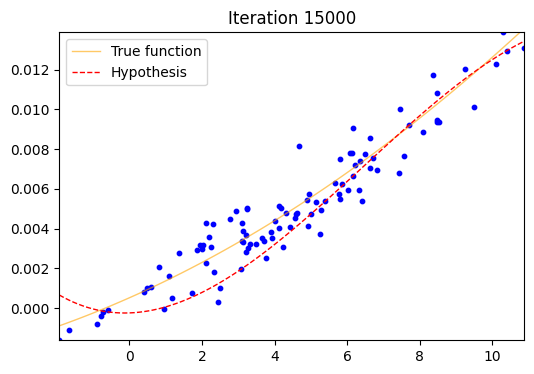

In [24]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.scatter(x_vals[0, :], y_vals, color="blue", s=10)

x_line = np.linspace(min(x_vals[0, :]), max(x_vals[0, :]), 100)
x_line_original = polynomial_features(x_line, degree_of_polynomial)
x_line_hypothesis = polynomial_features(x_line, hypothesis_degree_of_polynomial)

ax.plot(
    x_line, f(x_line_original),
    color="orange", lw=1, alpha=0.6, label="True function"
)

hyp_line, = ax.plot(
    x_line, hypothesis(x_line_hypothesis),
    color="red", lw=1, linestyle="--", label="Hypothesis"
)

ax.legend()
ax.set_xlim(min(x_vals[0, :]), max(x_vals[0, :]))
ax.set_ylim(min(y_vals), max(y_vals))

frame_id = 0
MSE_vals = []

for i in range(n_iter):

    # SGD update FIRST
    model_params -= learning_rate * grad()

    # Update plot
    hyp_line.set_ydata(hypothesis(x_line_hypothesis))
    ax.set_title(f"Iteration {i+1}")

    # Save frame
    if i % 5 == 0:
        plt.savefig(
            os.path.join(DIR, f"frames_poly/frame_{frame_id:05d}.png"),
            # bbox_inches="tight"
        )
        frame_id += 1

    MSE_vals.append(MSE(y_vals, hypothesis(x_vals_hyp)))


In [17]:
!pwd

/Users/mandakausthubh/ML_Research/StatML/Statistical-Machine-Learning-AIM-102-2026/Week1


In [20]:
!ffmpeg -framerate 10 -i ./frames_poly/frame_%04d.png sgd_poly.gif

ffmpeg version 8.0.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with Apple clang version 17.0.0 (clang-1700.4.4.1)
  configuration: --prefix=/opt/homebrew/Cellar/ffmpeg/8.0.1 --enable-shared --enable-pthreads --enable-version3 --cc=clang --host-cflags= --host-ldflags= --enable-ffplay --enable-gnutls --enable-gpl --enable-libaom --enable-libaribb24 --enable-libbluray --enable-libdav1d --enable-libharfbuzz --enable-libjxl --enable-libmp3lame --enable-libopus --enable-librav1e --enable-librist --enable-librubberband --enable-libsnappy --enable-libsrt --enable-libssh --enable-libsvtav1 --enable-libtesseract --enable-libtheora --enable-libvidstab --enable-libvmaf --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx264 --enable-libx265 --enable-libxml2 --enable-libxvid --enable-lzma --enable-libfontconfig --enable-libfreetype --enable-frei0r --enable-libass --enable-libopencore-amrnb --enable-libopencore-amrwb --enable-libopenjpeg --enable-libspeex --enable-libsoxr --

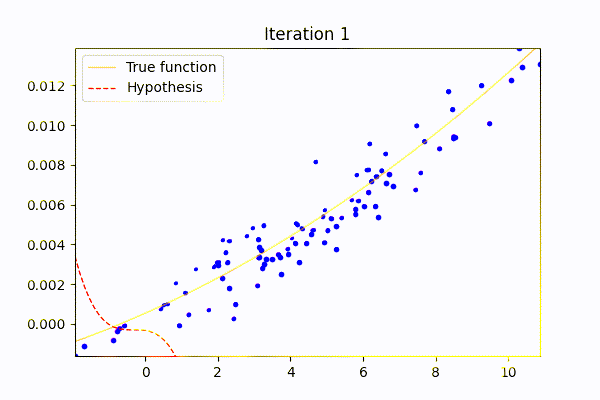

In [21]:
from IPython.display import Image, display

display(Image(filename=os.path.join(DIR, "sgd_poly.gif")))

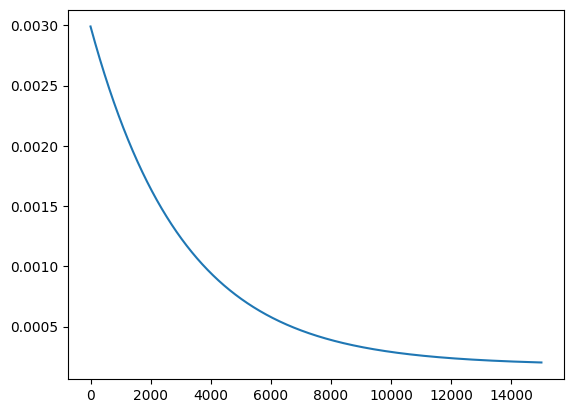

In [25]:
plt.plot(MSE_vals)

# Looking at Direct Solutions

In [26]:
best_params = np.linalg.inv(x_vals_hyp @ x_vals_hyp.T) @ x_vals_hyp @ y_vals

In [27]:
best_params

array([ 9.58099423e-04, -1.04083127e-05,  3.31604565e-06,  4.59633331e-04])